# ToDo

# Подготовка

## Настройка графики

In [1]:
#windows.options(height=5.4, width=7)
oldpar = par()
par(mar = c(8, 4, 1, 2), "xpd" = FALSE)
options(repr.plot.height = 9, repr.plot.width = 12)
options(warn = -1)

## Библиотеки

In [2]:
options(java.parameters = "-Xmx4096m")

require(readxl, quietly = TRUE, warn.conflicts = FALSE);

require(vcd, quietly = TRUE, warn.conflicts = FALSE);
require(coin, quietly = TRUE, warn.conflicts = FALSE);          # independence_test
require(agricolae, quietly = TRUE, warn.conflicts = FALSE);     # HSD.test
require(pgirmess, quietly = TRUE, warn.conflicts = FALSE);      # kruskalmc
require(nortest, quietly = TRUE, warn.conflicts = FALSE);       # for normality test in case of N>5000. ad.test -- Anderson-Darling normality test
require(RcmdrMisc, quietly = TRUE, warn.conflicts = FALSE);     # numSumm

require(beeswarm, quietly = TRUE, warn.conflicts = FALSE);
require(lattice, quietly = TRUE, warn.conflicts = FALSE);
require(mosaic, quietly = TRUE, warn.conflicts = FALSE);
require(ggplot2, quietly = TRUE, warn.conflicts = FALSE);
require(ggpubr, quietly = TRUE, warn.conflicts = FALSE);        # ggqqplot
#require(ggExtra, quietly = TRUE, warn.conflicts = FALSE);
#require(gridExtra, quietly = TRUE, warn.conflicts = FALSE);
#require(ggfortify, quietly = TRUE, warn.conflicts = FALSE);
require(ggalluvial, quietly = TRUE);                            # flow diagramm
require(hrbrthemes, quietly = TRUE, warn.conflicts = FALSE);    # ggparcoord
require(GGally, quietly = TRUE, warn.conflicts = FALSE);        # ggparcoord
require(viridis, quietly = TRUE, warn.conflicts = FALSE);       # ggparcoord


require(rstatix, quietly = TRUE);                               # identify_outliers
require(dplyr, quietly = TRUE, warn.conflicts = FALSE);
require(tidyr, quietly = TRUE, warn.conflicts = FALSE);
require(tidycmprsk, quietly = TRUE, warn.conflicts = FALSE);
#require(tidyverse, quietly = TRUE, warn.conflicts = FALSE);

require(IRdisplay, quietly = TRUE, warn.conflicts = FALSE);
require(repr, quietly = TRUE, warn.conflicts = FALSE);

require(knitr, quietly = TRUE, warn.conflicts = FALSE);        # Dynamic reports

Registered S3 method overwritten by 'mosaic':
  method                           from   
  fortify.SpatialPolygonsDataFrame ggplot2




The 'mosaic' package masks several functions from core packages in order to add 
additional features.  The original behavior of these functions should not be affected by this.



Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2




Attaching package: 'rstatix'




The following objects are masked from 'package:mosaic':

    cor_test, prop_test, t_test




The following objects are masked from 'package:coin':

    chisq_test, friedman_test, kruskal_test, sign_test, wilcox_test




The following object is masked from 'package:stats':

    filter




## Данные

### Загрузка

In [3]:
#sessionInfo()
#options(encoding = "UTF-8")
lor = read_excel("C:\\Analysis\\OTOLARING\\Nidelko\\mucous20240825.xlsx", sheet="данные")
# lor = as.data.frame(lor)

### Преобразование

#### Отбор данных

In [4]:
lor = lor %>% 
    dplyr::select("id", "группа", "локация", "этап", "поле", "круглоклеточная воспалительная инфильтрация", 
                  "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия", 
                  "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
                  ) %>%
    filter(локация != "полип") %>%
    filter(группа != "КГ1")
lor = as.data.frame(lor)

#### Контрасты

In [5]:
lor$группа = factor(lor$группа, c("ОГ", "КГ"))
lor$"локация" = factor(lor$"локация")
lor$"этап" = factor(lor$"этап", c("день операции", "6-7 сутки", "1-3 мес.", "1 год"))

#### Медианные значения

In [6]:
lor_mean <- lor %>%
    group_by(id, группа, локация, этап) %>%
    summarise(
        across(c(
                "круглоклеточная воспалительная инфильтрация", 
                  "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия", 
                  "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
                ),
            ~ median(.x, na.rm = TRUE)
        ),
        .groups = "drop"
        # mean_value = mean(measurement_value, na.rm = TRUE),
        # median_value = median(measurement_value, na.rm = TRUE),
        # sd_value = sd(measurement_value, na.rm = TRUE),
        # min_value = min(measurement_value, na.rm = TRUE),
        # max_value = max(measurement_value, na.rm = TRUE)
    ) %>%
    arrange(id) 
# %>%
#     kable(digits = 2)
# lor_mean

### Подключение

In [7]:
lor = lor_mean
try(detach(lor), silent = TRUE)
attach(lor)

# Общий анализ

In [8]:
groupping_variable = 'группа'

## круглоклеточная воспалительная инфильтрация

### Общее

In [9]:
parname = "круглоклеточная воспалительная инфильтрация"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

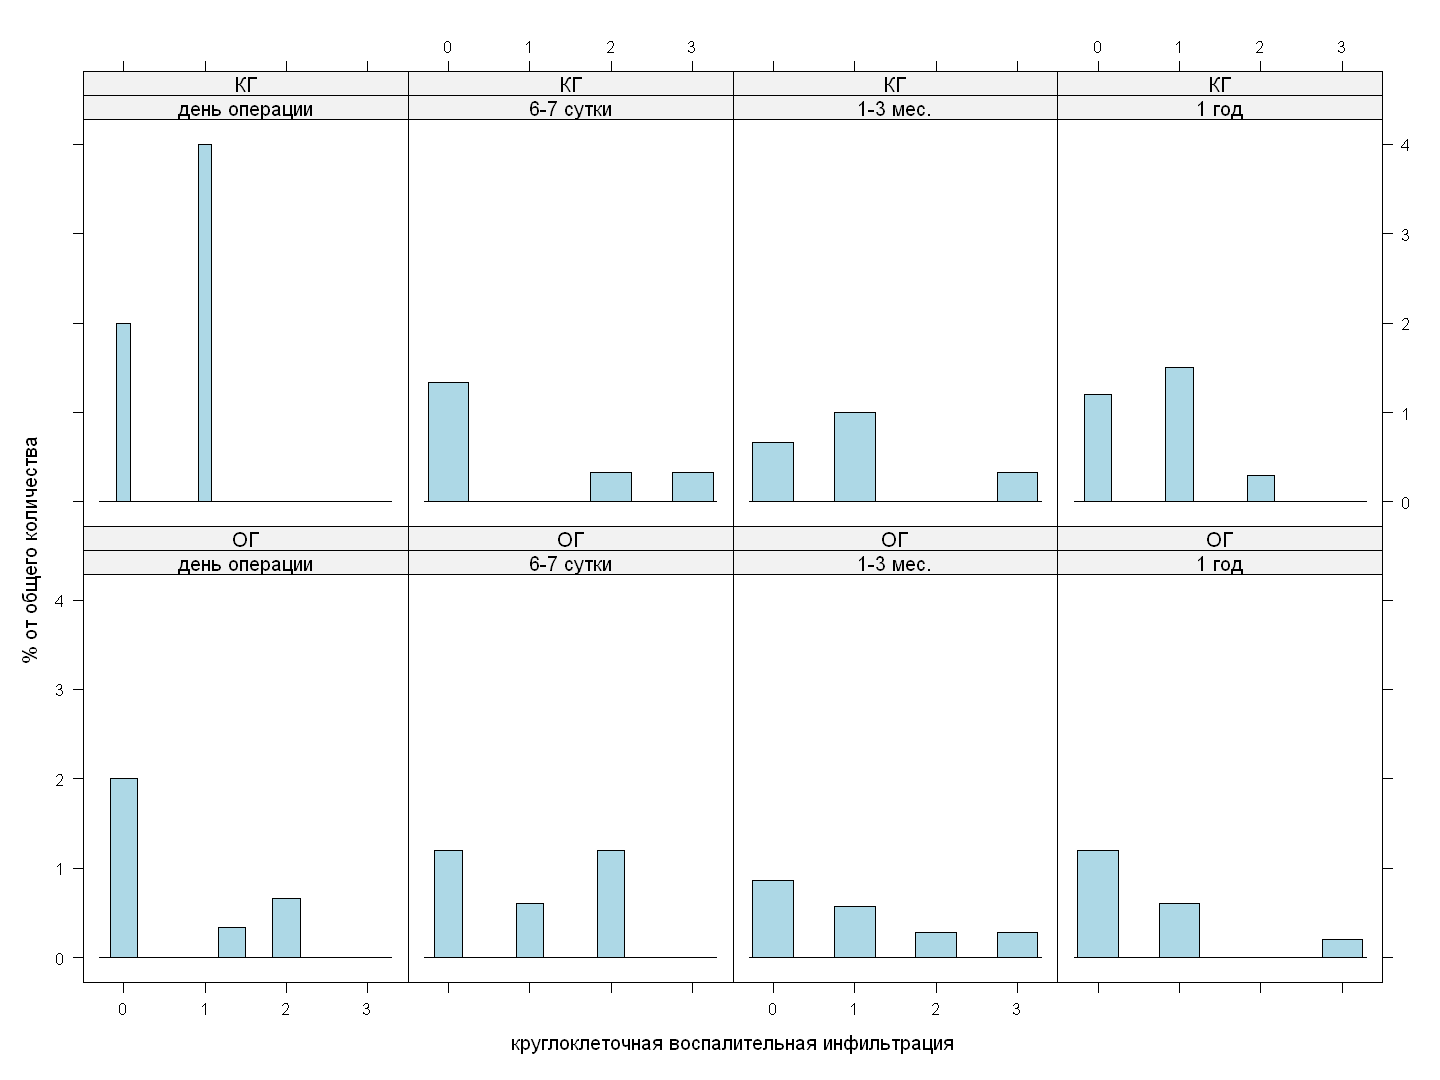

In [10]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [11]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd  IQR 0%  25% 50% 75% 100% data:n
КГ: 1-3 мес.      1.0000000 1.0954451 0.75  0 0.25   1 1.0    3      6
КГ: 1 год         0.7000000 0.6749486 1.00  0 0.00   1 1.0    2     10
КГ: 6-7 сутки     0.8333333 1.3291601 1.50  0 0.00   0 1.5    3      6
КГ: день операции 0.6666667 0.5773503 0.50  0 0.50   1 1.0    1      3
ОГ: 1-3 мес.      1.0000000 1.1547005 1.50  0 0.00   1 1.5    3      7
ОГ: 1 год         0.6000000 0.9660918 1.00  0 0.00   0 1.0    3     10
ОГ: 6-7 сутки     1.0000000 1.0000000 2.00  0 0.00   1 2.0    2      5
ОГ: день операции 0.6111111 0.9279607 1.50  0 0.00   0 1.5    2      9

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0.00,0,1.5,2,0.6111111,0.9279607,9,0
КГ.день операции,0,0.50,1,1.0,1,0.6666667,0.5773503,3,0
ОГ.6-7 сутки,0,0.00,1,2.0,2,1.0000000,1.0000000,5,0
КГ.6-7 сутки,0,0.00,0,1.5,3,0.8333333,1.3291601,6,0
ОГ.1-3 мес.,0,0.00,1,1.5,3,1.0000000,1.1547005,7,0
КГ.1-3 мес.,0,0.25,1,1.0,3,1.0000000,1.0954451,6,0
ОГ.1 год,0,0.00,0,1.0,3,0.6000000,0.9660918,10,0
КГ.1 год,0,0.00,1,1.0,2,0.7000000,0.6749486,10,0


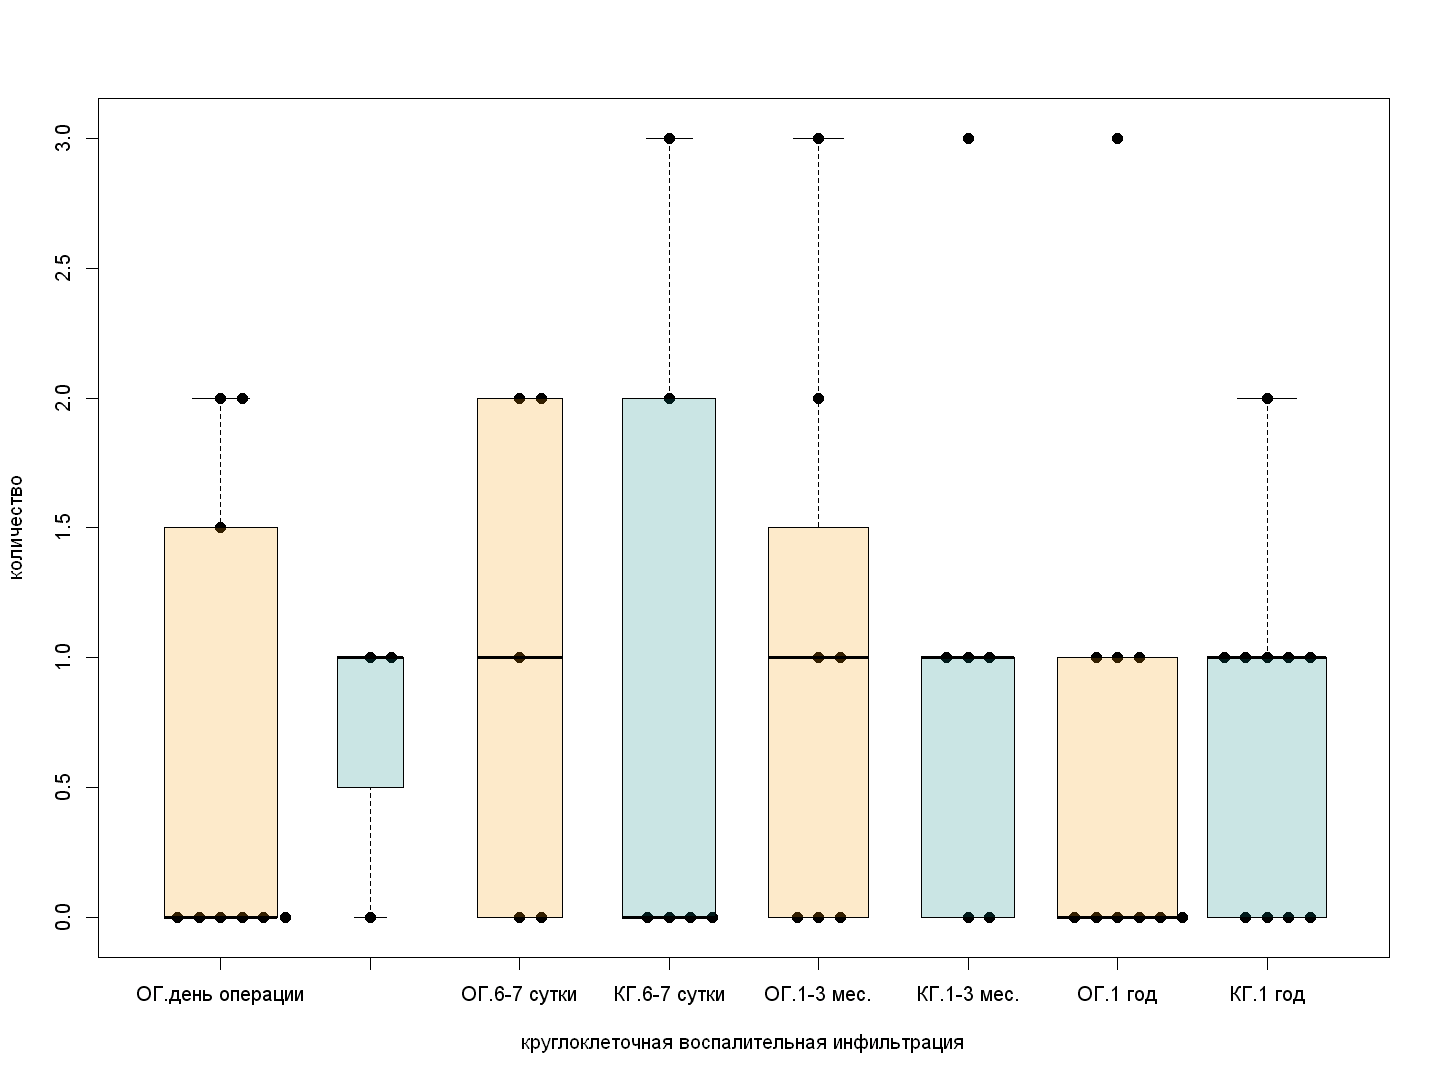

In [12]:
parname = sub("\\..*", "", parname)
beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
         , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", add = TRUE, varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [13]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 12, p-value = 0.8359
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -0.31063, p-value = 0.7561
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 17, p-value = 0.7627
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.40257, p-value = 0.6873
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 20.5, p-value = 1
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -0.075827, p-value = 0.9396


## бокаловидные клетки

### Общее

In [14]:
parname = "бокаловидные клетки"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

In [15]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [16]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd  IQR 0% 25% 50%  75% 100% data:n
КГ: 1-3 мес.      0.5000000 0.8366600 0.75  0   0   0 0.75    2      6
КГ: 1 год         0.5000000 0.9718253 0.75  0   0   0 0.75    3     10
КГ: 6-7 сутки     0.0000000 0.0000000 0.00  0   0   0 0.00    0      6
КГ: день операции 0.0000000 0.0000000 0.00  0   0   0 0.00    0      3
ОГ: 1-3 мес.      0.7142857 0.7559289 1.00  0   0   1 1.00    2      7
ОГ: 1 год         0.4000000 0.9660918 0.00  0   0   0 0.00    3     10
ОГ: 6-7 сутки     0.0000000 0.0000000 0.00  0   0   0 0.00    0      5
ОГ: день операции 0.0000000 0.0000000 0.00  0   0   0 0.00    0      9

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0,0.00,0,0.0000000,0.0000000,9,0
КГ.день операции,0,0,0,0.00,0,0.0000000,0.0000000,3,0
ОГ.6-7 сутки,0,0,0,0.00,0,0.0000000,0.0000000,5,0
КГ.6-7 сутки,0,0,0,0.00,0,0.0000000,0.0000000,6,0
ОГ.1-3 мес.,0,0,1,1.00,2,0.7142857,0.7559289,7,0
КГ.1-3 мес.,0,0,0,0.75,2,0.5000000,0.8366600,6,0
ОГ.1 год,0,0,0,0.00,3,0.4000000,0.9660918,10,0
КГ.1 год,0,0,0,0.75,3,0.5000000,0.9718253,10,0


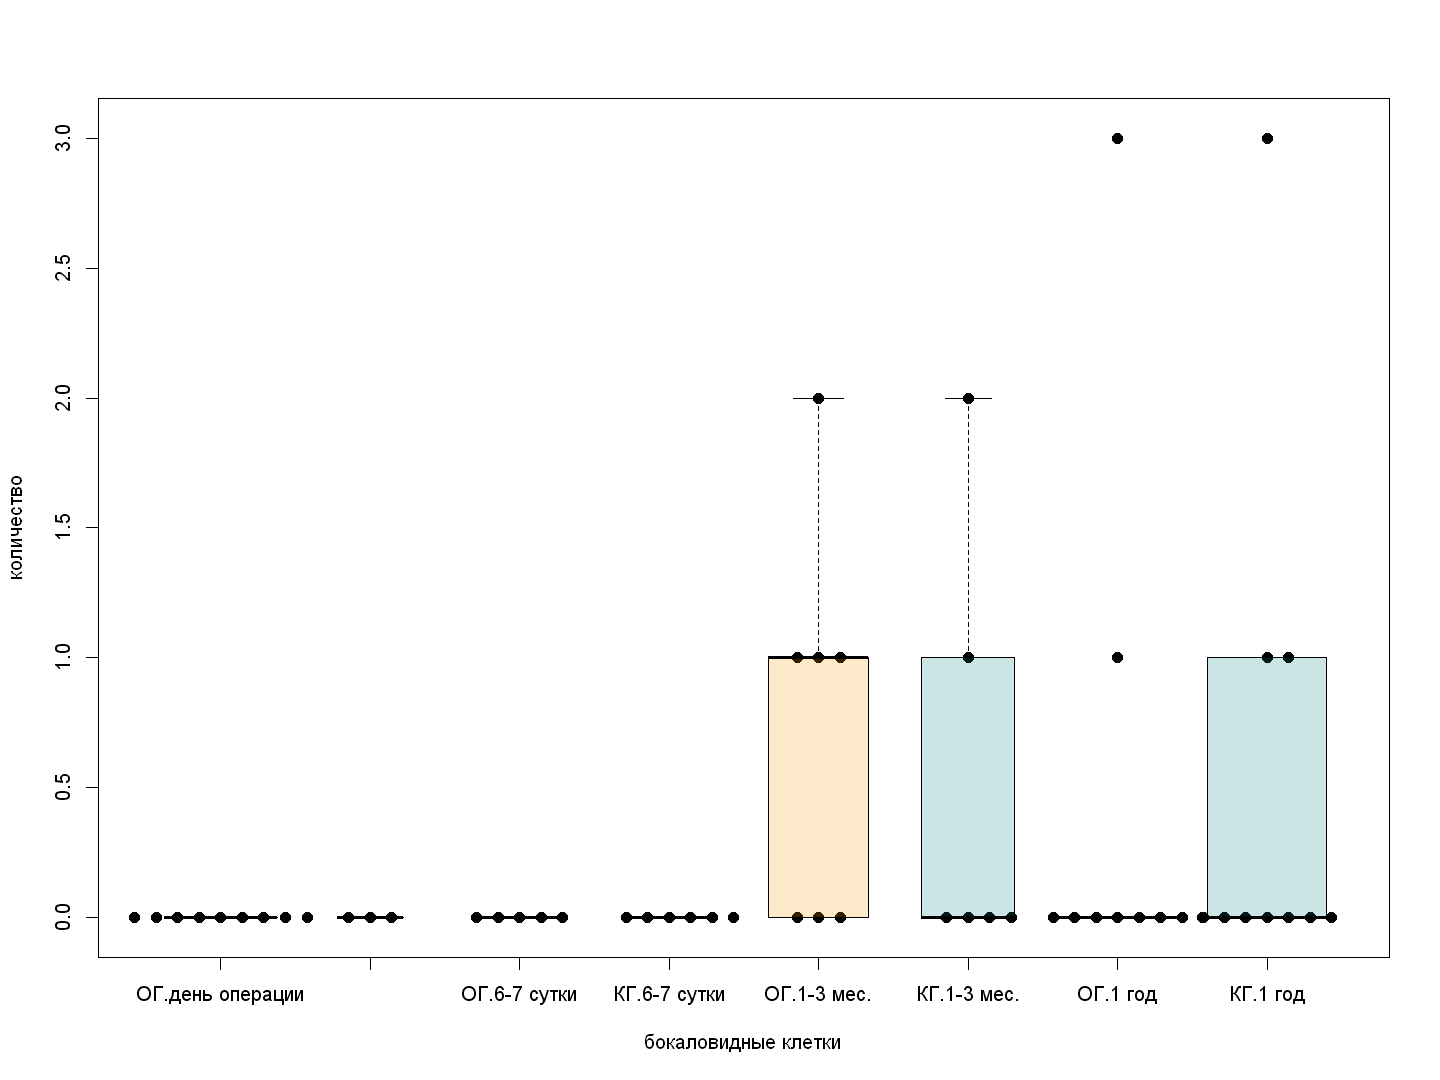

In [17]:
parname = sub("\\..*", "", parname)
beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
         , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", add = TRUE, varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [18]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 13.5, p-value = NA
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = NaN, p-value = NA
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 15, p-value = NA
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = NaN, p-value = NA
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 25, p-value = 0.5799
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.63261, p-value = 0.527
alternative hypothesis:

## отек

### Общее

In [19]:
parname = "отек"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

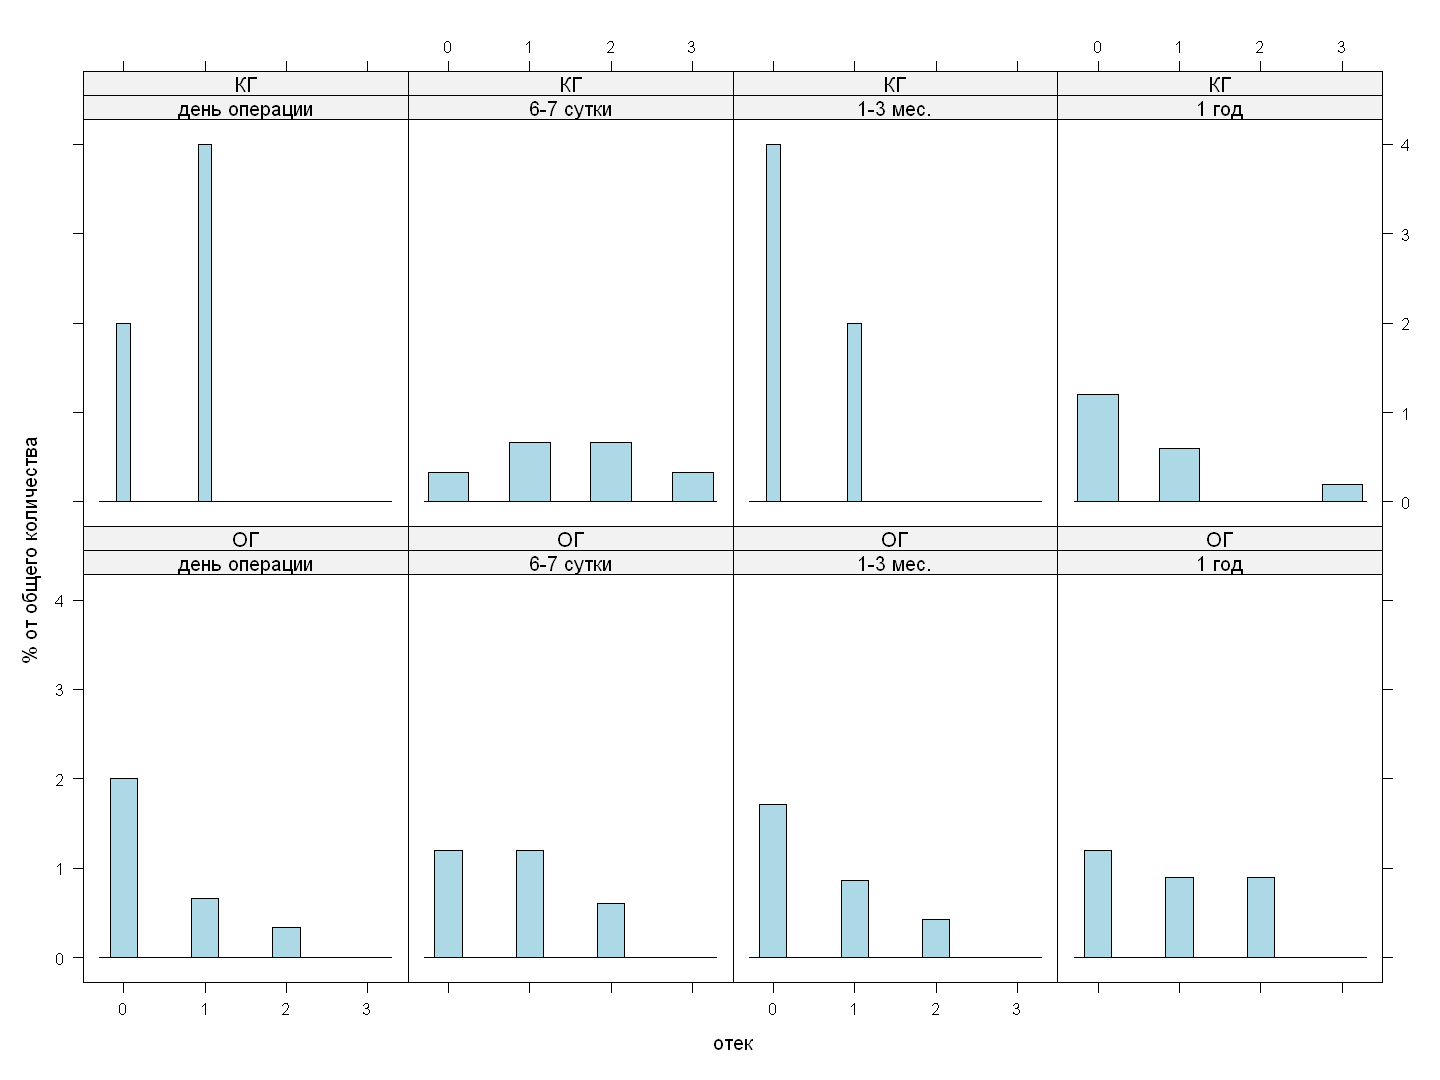

In [20]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [21]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd  IQR 0% 25% 50%  75% 100% data:n
КГ: 1-3 мес.      0.3333333 0.5163978 0.75  0 0.0 0.0 0.75    1      6
КГ: 1 год         0.6000000 0.9660918 1.00  0 0.0 0.0 1.00    3     10
КГ: 6-7 сутки     1.5000000 1.0488088 1.00  0 1.0 1.5 2.00    3      6
КГ: день операции 0.6666667 0.5773503 0.50  0 0.5 1.0 1.00    1      3
ОГ: 1-3 мес.      0.5714286 0.7867958 1.00  0 0.0 0.0 1.00    2      7
ОГ: 1 год         0.9000000 0.8755950 1.75  0 0.0 1.0 1.75    2     10
ОГ: 6-7 сутки     0.8000000 0.8366600 1.00  0 0.0 1.0 1.00    2      5
ОГ: день операции 0.4444444 0.7264832 1.00  0 0.0 0.0 1.00    2      9

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0.0,0.0,1.00,2,0.4444444,0.7264832,9,0
КГ.день операции,0,0.5,1.0,1.00,1,0.6666667,0.5773503,3,0
ОГ.6-7 сутки,0,0.0,1.0,1.00,2,0.8000000,0.8366600,5,0
КГ.6-7 сутки,0,1.0,1.5,2.00,3,1.5000000,1.0488088,6,0
ОГ.1-3 мес.,0,0.0,0.0,1.00,2,0.5714286,0.7867958,7,0
КГ.1-3 мес.,0,0.0,0.0,0.75,1,0.3333333,0.5163978,6,0
ОГ.1 год,0,0.0,1.0,1.75,2,0.9000000,0.8755950,10,0
КГ.1 год,0,0.0,0.0,1.00,3,0.6000000,0.9660918,10,0


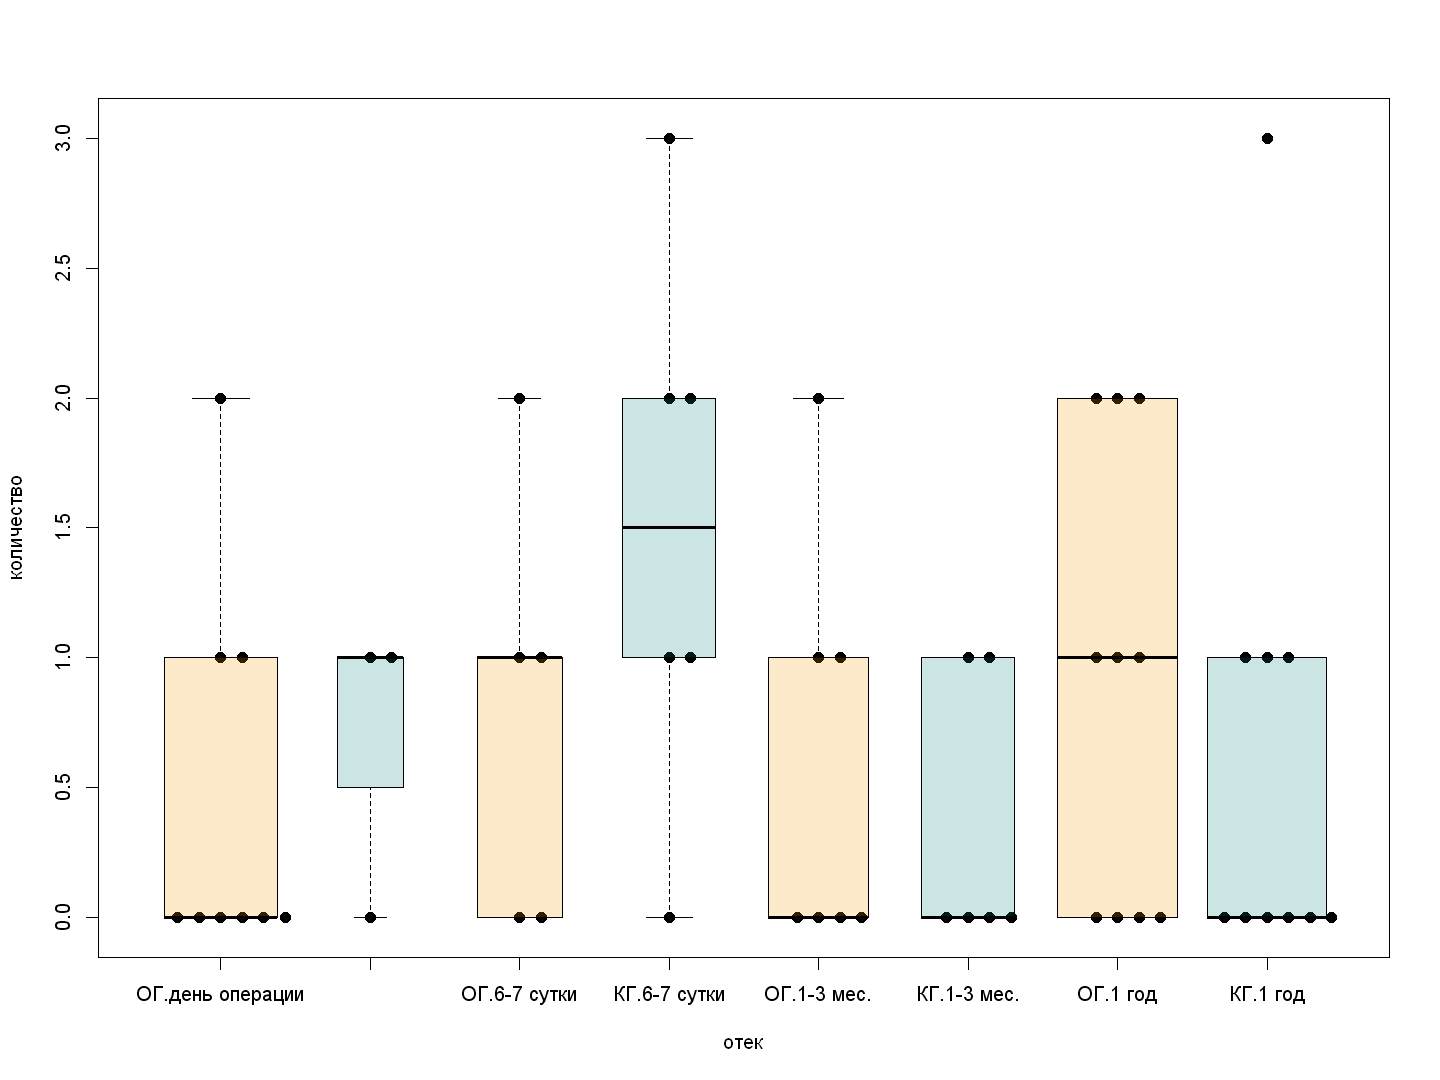

In [22]:
parname = sub("\\..*", "", parname)
beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
         , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", add = TRUE, varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [23]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 10, p-value = 0.5271
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -0.73786, p-value = 0.4606
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 9, p-value = 0.2947
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -1.1432, p-value = 0.253
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 24, p-value = 0.6784
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.49761, p-value = 0.6188
a

## реснички эпителия

### Общее

In [24]:
parname = "реснички эпителия"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

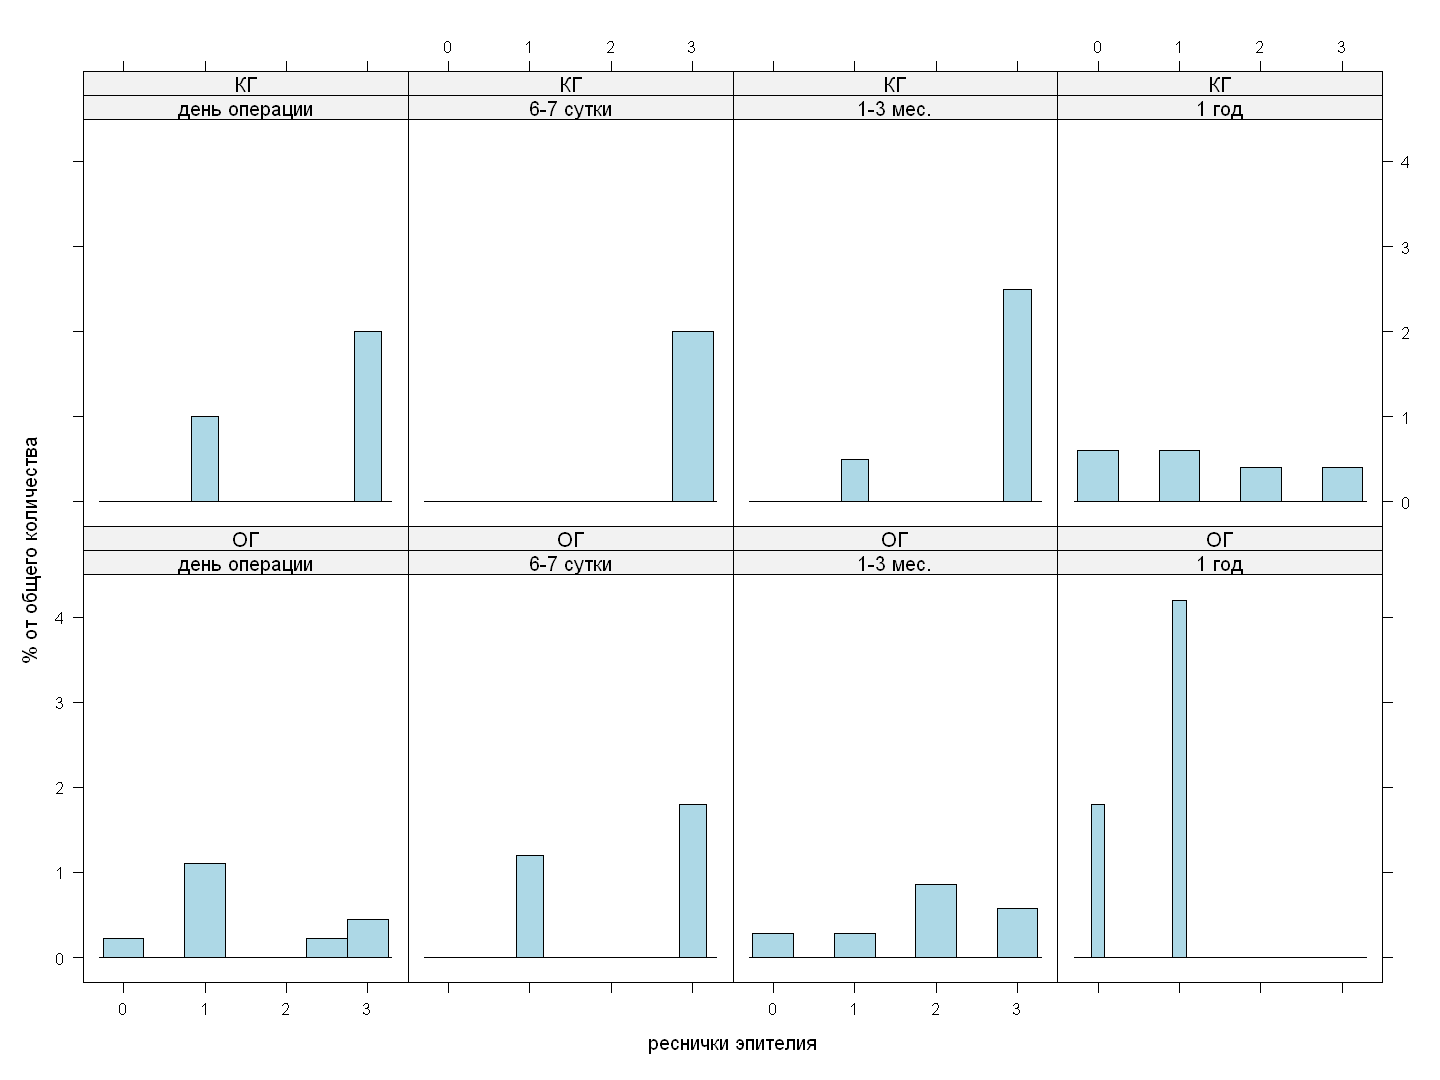

In [25]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [26]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                      mean        sd  IQR 0%  25% 50% 75% 100% data:n
КГ: 1-3 мес.      2.666667 0.8164966 0.00  1 3.00   3 3.0    3      6
КГ: 1 год         1.300000 1.1595018 1.75  0 0.25   1 2.0    3     10
КГ: 6-7 сутки     3.000000 0.0000000 0.00  3 3.00   3 3.0    3      6
КГ: день операции 2.333333 1.1547005 1.00  1 2.00   3 3.0    3      3
ОГ: 1-3 мес.      1.857143 1.0690450 1.00  0 1.50   2 2.5    3      7
ОГ: 1 год         0.700000 0.4830459 0.75  0 0.25   1 1.0    1     10
ОГ: 6-7 сутки     2.200000 1.0954451 2.00  1 1.00   3 3.0    3      5
ОГ: день операции 1.500000 1.0606602 1.50  0 1.00   1 2.5    3      9

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,1.00,1,2.5,3,1.500000,1.0606602,9,0
КГ.день операции,1,2.00,3,3.0,3,2.333333,1.1547005,3,0
ОГ.6-7 сутки,1,1.00,3,3.0,3,2.200000,1.0954451,5,0
КГ.6-7 сутки,3,3.00,3,3.0,3,3.000000,0.0000000,6,0
ОГ.1-3 мес.,0,1.50,2,2.5,3,1.857143,1.0690450,7,0
КГ.1-3 мес.,1,3.00,3,3.0,3,2.666667,0.8164966,6,0
ОГ.1 год,0,0.25,1,1.0,1,0.700000,0.4830459,10,0
КГ.1 год,0,0.25,1,2.0,3,1.300000,1.1595018,10,0


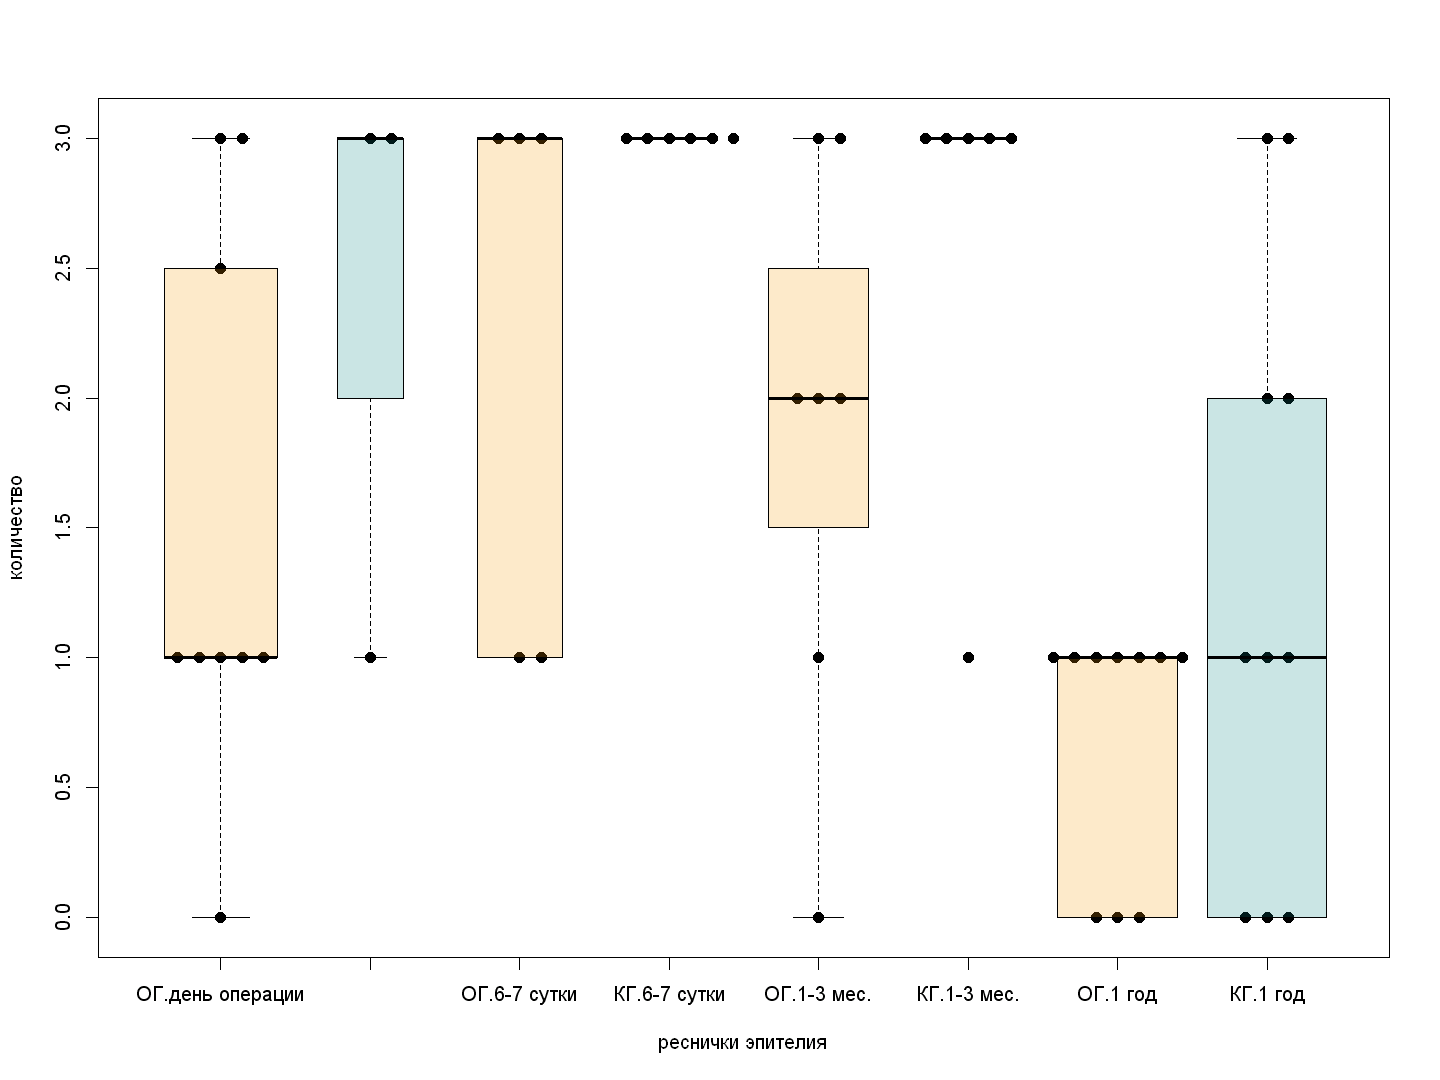

In [27]:
parname = sub("\\..*", "", parname)
beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
         , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", add = TRUE, varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [28]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 7.5, p-value = 0.2679
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -1.2085, p-value = 0.2268
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 9, p-value = 0.1344
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -1.633, p-value = 0.1025
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 10.5, p-value = 0.1174
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -1.6441, p-value = 0.1002

## фиброз

### Общее

In [29]:
parname = "фиброз"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

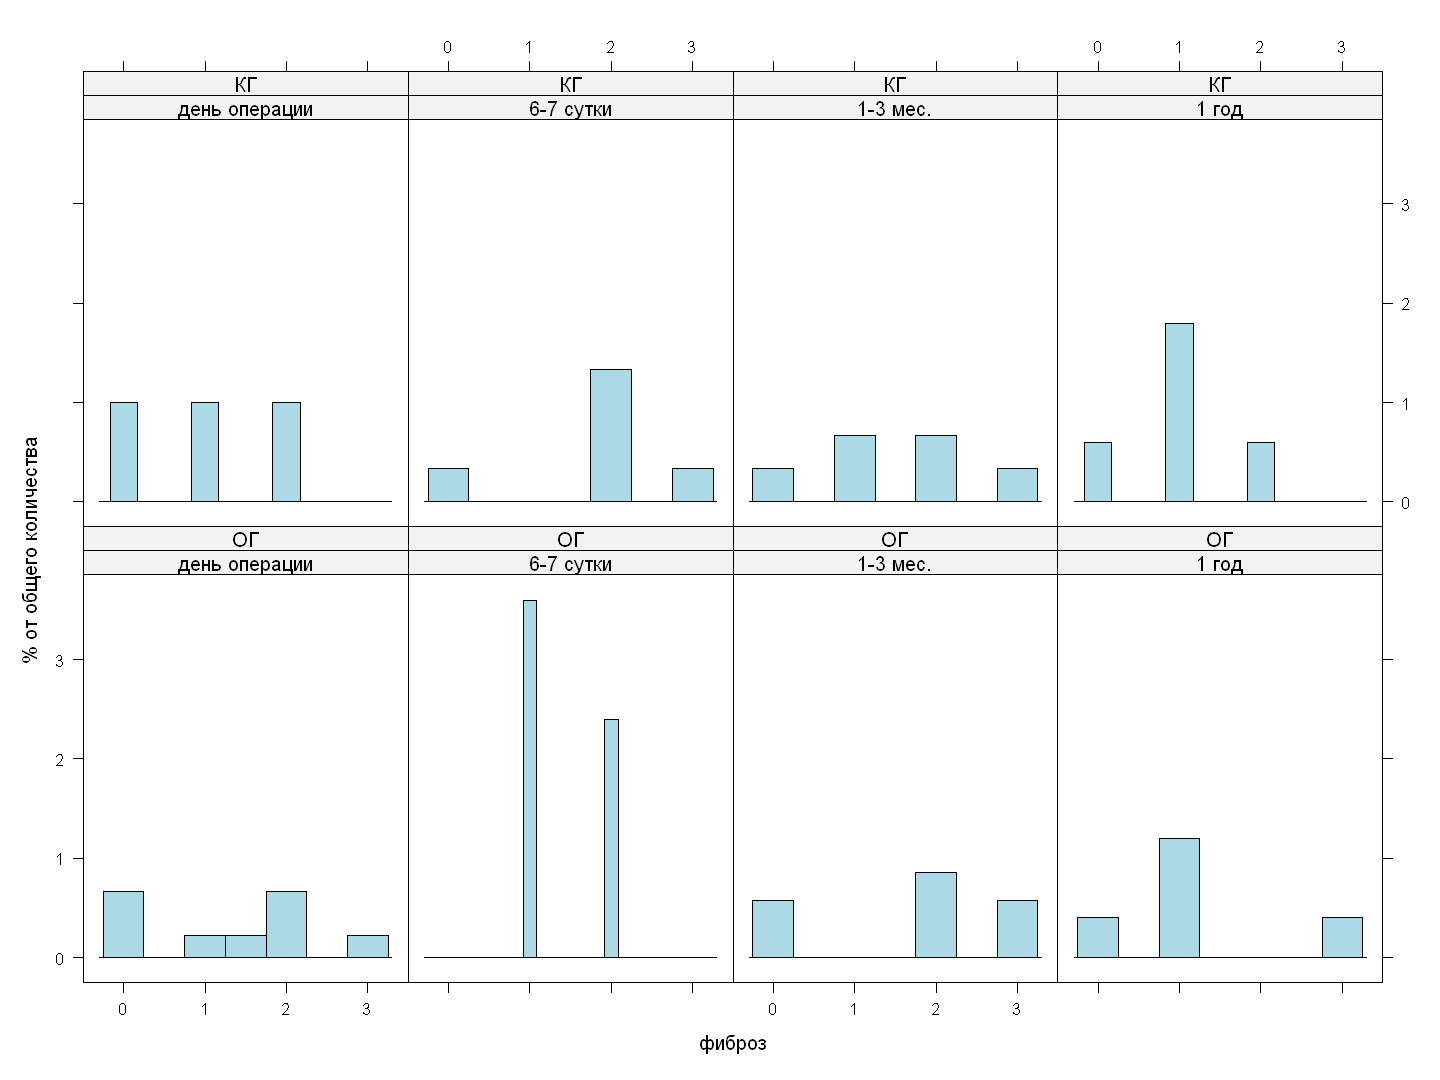

In [30]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [31]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                      mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.      1.500000 1.0488088 1.0  0 1.0 1.5 2.0    3      6
КГ: 1 год         1.000000 0.6666667 0.0  0 1.0 1.0 1.0    2     10
КГ: 6-7 сутки     1.833333 0.9831921 0.0  0 2.0 2.0 2.0    3      6
КГ: день операции 1.000000 1.0000000 1.0  0 0.5 1.0 1.5    2      3
ОГ: 1-3 мес.      1.714286 1.2535663 1.5  0 1.0 2.0 2.5    3      7
ОГ: 1 год         1.200000 1.0327956 0.0  0 1.0 1.0 1.0    3     10
ОГ: 6-7 сутки     1.400000 0.5477226 1.0  1 1.0 1.0 2.0    2      5
ОГ: день операции 1.277778 1.0929064 2.0  0 0.0 1.5 2.0    3      9

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0.0,1.5,2.0,3,1.277778,1.0929064,9,0
КГ.день операции,0,0.5,1.0,1.5,2,1.000000,1.0000000,3,0
ОГ.6-7 сутки,1,1.0,1.0,2.0,2,1.400000,0.5477226,5,0
КГ.6-7 сутки,0,2.0,2.0,2.0,3,1.833333,0.9831921,6,0
ОГ.1-3 мес.,0,1.0,2.0,2.5,3,1.714286,1.2535663,7,0
КГ.1-3 мес.,0,1.0,1.5,2.0,3,1.500000,1.0488088,6,0
ОГ.1 год,0,1.0,1.0,1.0,3,1.200000,1.0327956,10,0
КГ.1 год,0,1.0,1.0,1.0,2,1.000000,0.6666667,10,0


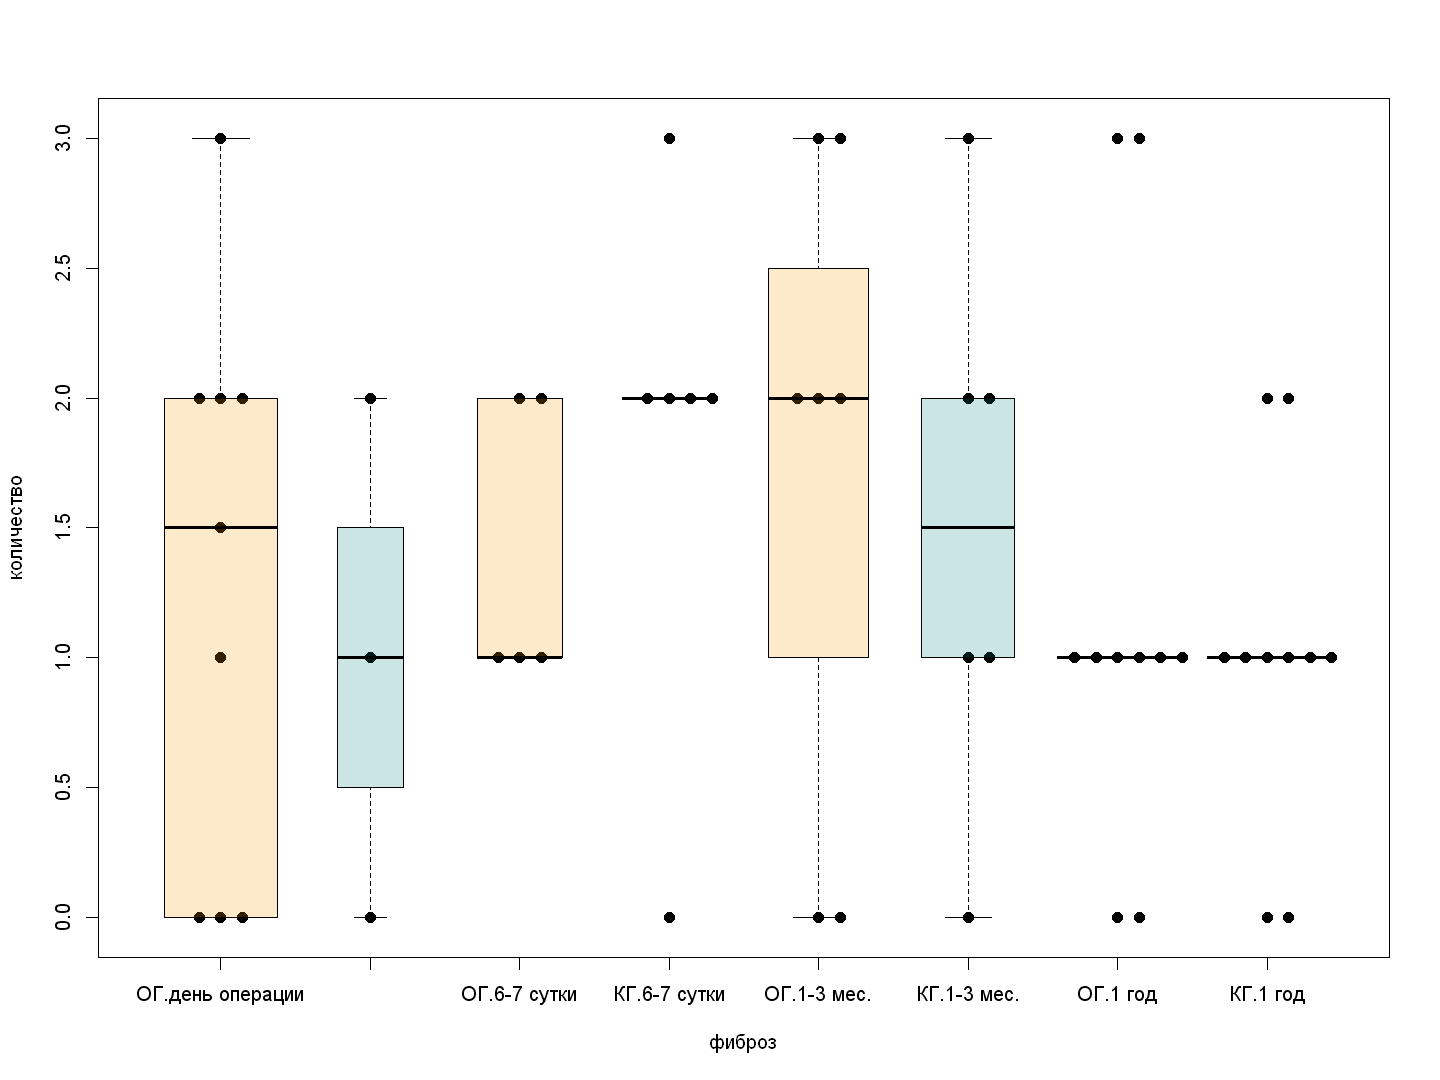

In [32]:
parname = sub("\\..*", "", parname)
beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
         , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", add = TRUE, varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [33]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 15.5, p-value = 0.7732
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.38417, p-value = 0.7009
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 9, p-value = 0.2683
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -1.2077, p-value = 0.2272
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 24, p-value = 0.7097
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.44674, p-value = 0.6551

## гиперплазия респираторного эпителия

### Общее

In [34]:
parname = "гиперплазия респираторного эпителия"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

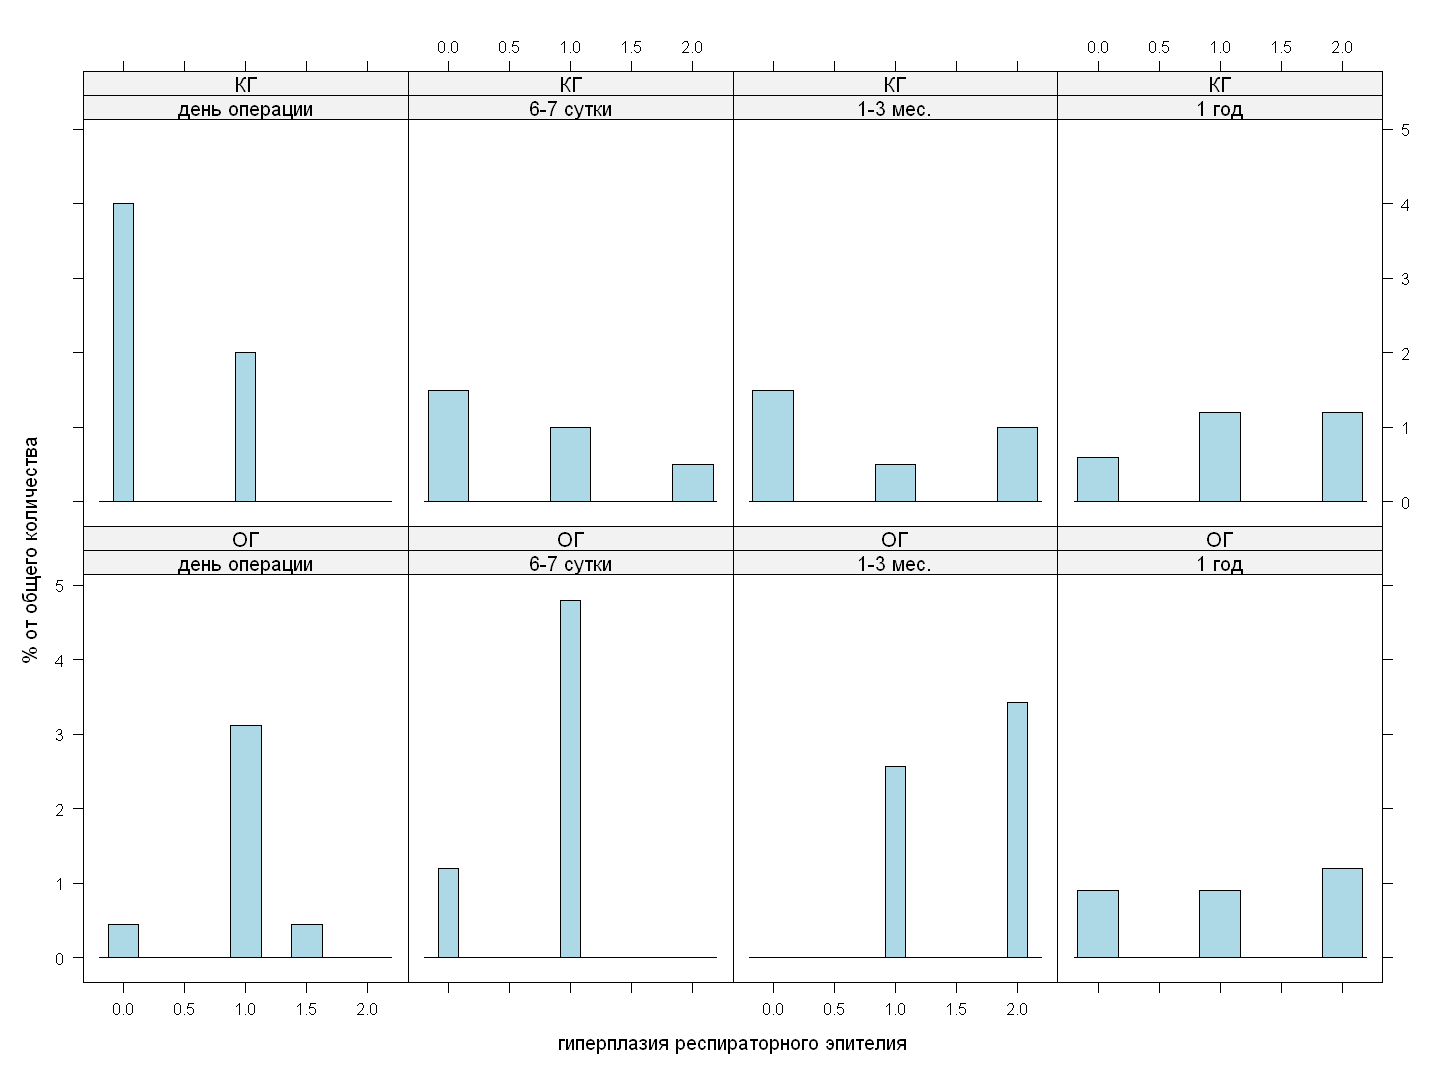

In [35]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [36]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd  IQR 0%  25% 50%  75% 100% data:n
КГ: 1-3 мес.      0.8333333 0.9831921 1.75  0 0.00 0.5 1.75  2.0      6
КГ: 1 год         1.2000000 0.7888106 1.00  0 1.00 1.0 2.00  2.0     10
КГ: 6-7 сутки     0.6666667 0.8164966 1.00  0 0.00 0.5 1.00  2.0      6
КГ: день операции 0.3333333 0.5773503 0.50  0 0.00 0.0 0.50  1.0      3
ОГ: 1-3 мес.      1.5714286 0.5345225 1.00  1 1.00 2.0 2.00  2.0      7
ОГ: 1 год         1.1000000 0.8755950 1.75  0 0.25 1.0 2.00  2.0     10
ОГ: 6-7 сутки     0.8000000 0.4472136 0.00  0 1.00 1.0 1.00  1.0      5
ОГ: день операции 0.9444444 0.3908680 0.00  0 1.00 1.0 1.00  1.5      9

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,1.00,1.0,1.00,1.5,0.9444444,0.3908680,9,0
КГ.день операции,0,0.00,0.0,0.50,1.0,0.3333333,0.5773503,3,0
ОГ.6-7 сутки,0,1.00,1.0,1.00,1.0,0.8000000,0.4472136,5,0
КГ.6-7 сутки,0,0.00,0.5,1.00,2.0,0.6666667,0.8164966,6,0
ОГ.1-3 мес.,1,1.00,2.0,2.00,2.0,1.5714286,0.5345225,7,0
КГ.1-3 мес.,0,0.00,0.5,1.75,2.0,0.8333333,0.9831921,6,0
ОГ.1 год,0,0.25,1.0,2.00,2.0,1.1000000,0.8755950,10,0
КГ.1 год,0,1.00,1.0,2.00,2.0,1.2000000,0.7888106,10,0


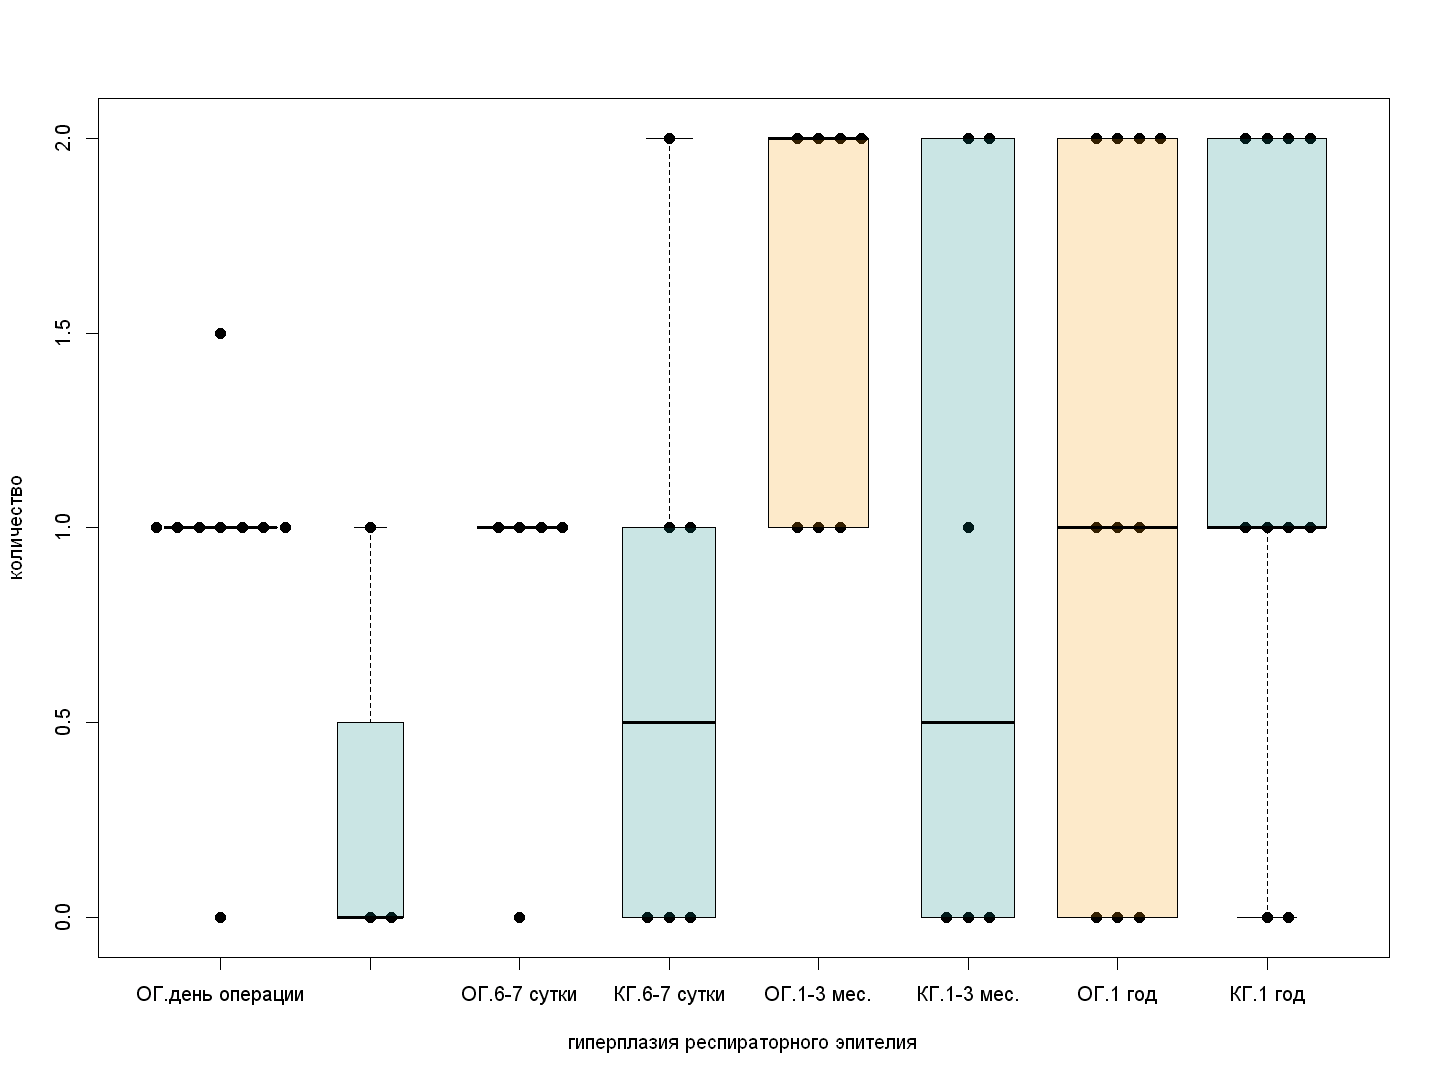

In [37]:
parname = sub("\\..*", "", parname)
beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
         , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", add = TRUE, varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [38]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 21.5, p-value = 0.09558
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 1.7778, p-value = 0.07544
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 17.5, p-value = 0.6822
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.51177, p-value = 0.6088
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 30.5, p-value = 0.1669
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 1.4589, p-value = 0

## плоскоклеточная метаплазия

### Общее

In [39]:
parname = "плоскоклеточная метаплазия"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

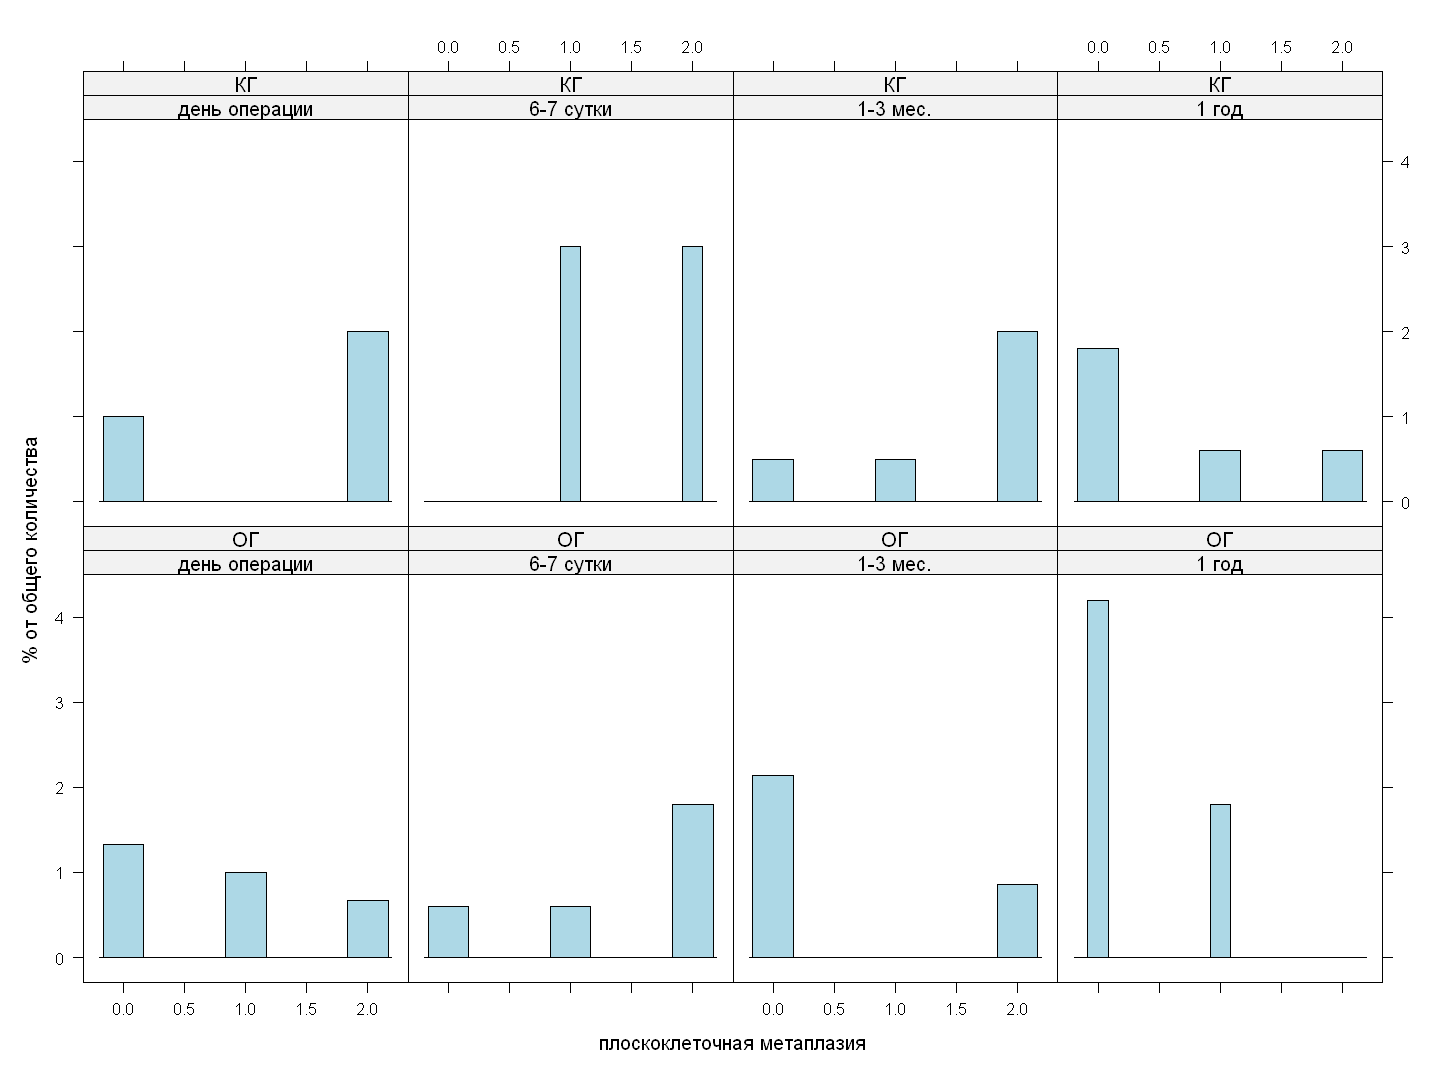

In [40]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [41]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd  IQR 0%  25% 50%  75% 100% data:n
КГ: 1-3 мес.      1.5000000 0.8366600 0.75  0 1.25 2.0 2.00    2      6
КГ: 1 год         0.6000000 0.8432740 1.00  0 0.00 0.0 1.00    2     10
КГ: 6-7 сутки     1.5000000 0.5477226 1.00  1 1.00 1.5 2.00    2      6
КГ: день операции 1.3333333 1.1547005 1.00  0 1.00 2.0 2.00    2      3
ОГ: 1-3 мес.      0.5714286 0.9759001 1.00  0 0.00 0.0 1.00    2      7
ОГ: 1 год         0.3000000 0.4830459 0.75  0 0.00 0.0 0.75    1     10
ОГ: 6-7 сутки     1.4000000 0.8944272 1.00  0 1.00 2.0 2.00    2      5
ОГ: день операции 0.7777778 0.8333333 1.00  0 0.00 1.0 1.00    2      9

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0.00,1.0,1.00,2,0.7777778,0.8333333,9,0
КГ.день операции,0,1.00,2.0,2.00,2,1.3333333,1.1547005,3,0
ОГ.6-7 сутки,0,1.00,2.0,2.00,2,1.4000000,0.8944272,5,0
КГ.6-7 сутки,1,1.00,1.5,2.00,2,1.5000000,0.5477226,6,0
ОГ.1-3 мес.,0,0.00,0.0,1.00,2,0.5714286,0.9759001,7,0
КГ.1-3 мес.,0,1.25,2.0,2.00,2,1.5000000,0.8366600,6,0
ОГ.1 год,0,0.00,0.0,0.75,1,0.3000000,0.4830459,10,0
КГ.1 год,0,0.00,0.0,1.00,2,0.6000000,0.8432740,10,0


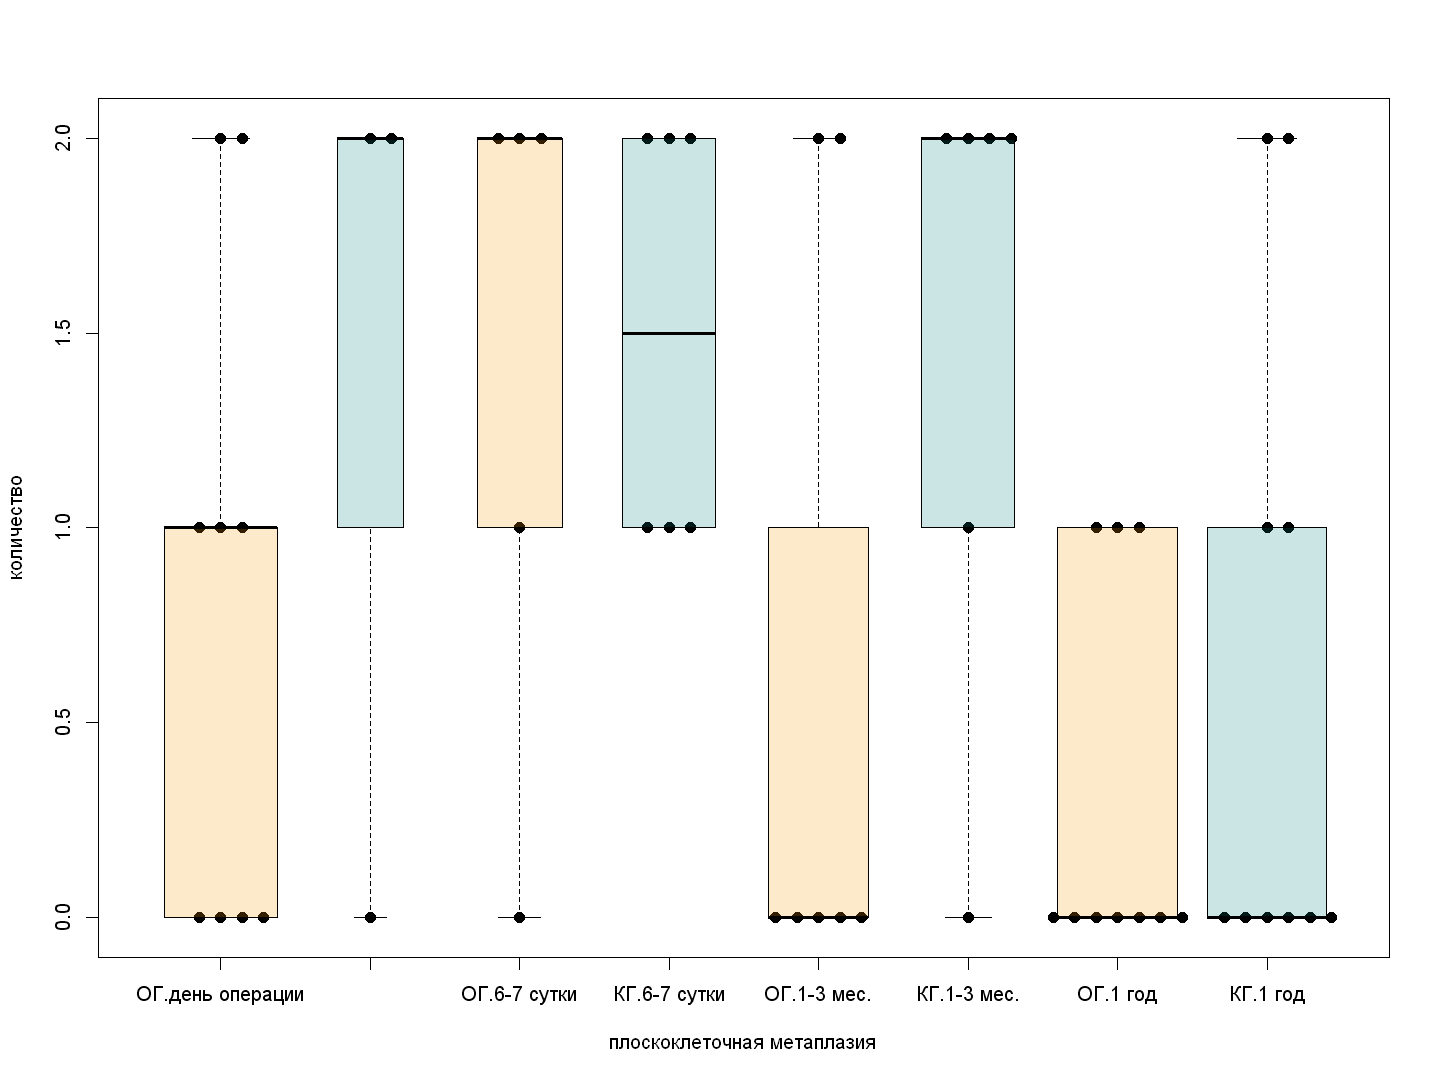

In [42]:
parname = sub("\\..*", "", parname)
beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
         , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", add = TRUE, varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [43]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 9, p-value = 0.4307
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -0.88641, p-value = 0.3754
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 15, p-value = 1
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0, p-value = 1
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 10.5, p-value = 0.1119
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -1.669, p-value = 0.09511
alternative hy

## эозинофилы

### Общее

In [44]:
parname = "эозинофилы"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

In [45]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [46]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd  IQR 0% 25% 50%  75% 100% data:n
КГ: 1-3 мес.      0.3333333 0.8164966 0.00  0   0   0 0.00    2      6
КГ: 1 год         0.7000000 1.2516656 0.75  0   0   0 0.75    3     10
КГ: 6-7 сутки     0.0000000 0.0000000 0.00  0   0   0 0.00    0      6
КГ: день операции 0.0000000 0.0000000 0.00  0   0   0 0.00    0      3
ОГ: 1-3 мес.      0.4285714 1.1338934 0.00  0   0   0 0.00    3      7
ОГ: 1 год         0.0000000 0.0000000 0.00  0   0   0 0.00    0     10
ОГ: 6-7 сутки     0.8000000 0.8366600 1.00  0   0   1 1.00    2      5
ОГ: день операции 0.5555556 1.1303883 0.00  0   0   0 0.00    3      9

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0,0.00,3,0.5555556,1.1303883,9,0
КГ.день операции,0,0,0,0.00,0,0.0000000,0.0000000,3,0
ОГ.6-7 сутки,0,0,1,1.00,2,0.8000000,0.8366600,5,0
КГ.6-7 сутки,0,0,0,0.00,0,0.0000000,0.0000000,6,0
ОГ.1-3 мес.,0,0,0,0.00,3,0.4285714,1.1338934,7,0
КГ.1-3 мес.,0,0,0,0.00,2,0.3333333,0.8164966,6,0
ОГ.1 год,0,0,0,0.00,0,0.0000000,0.0000000,10,0
КГ.1 год,0,0,0,0.75,3,0.7000000,1.2516656,10,0


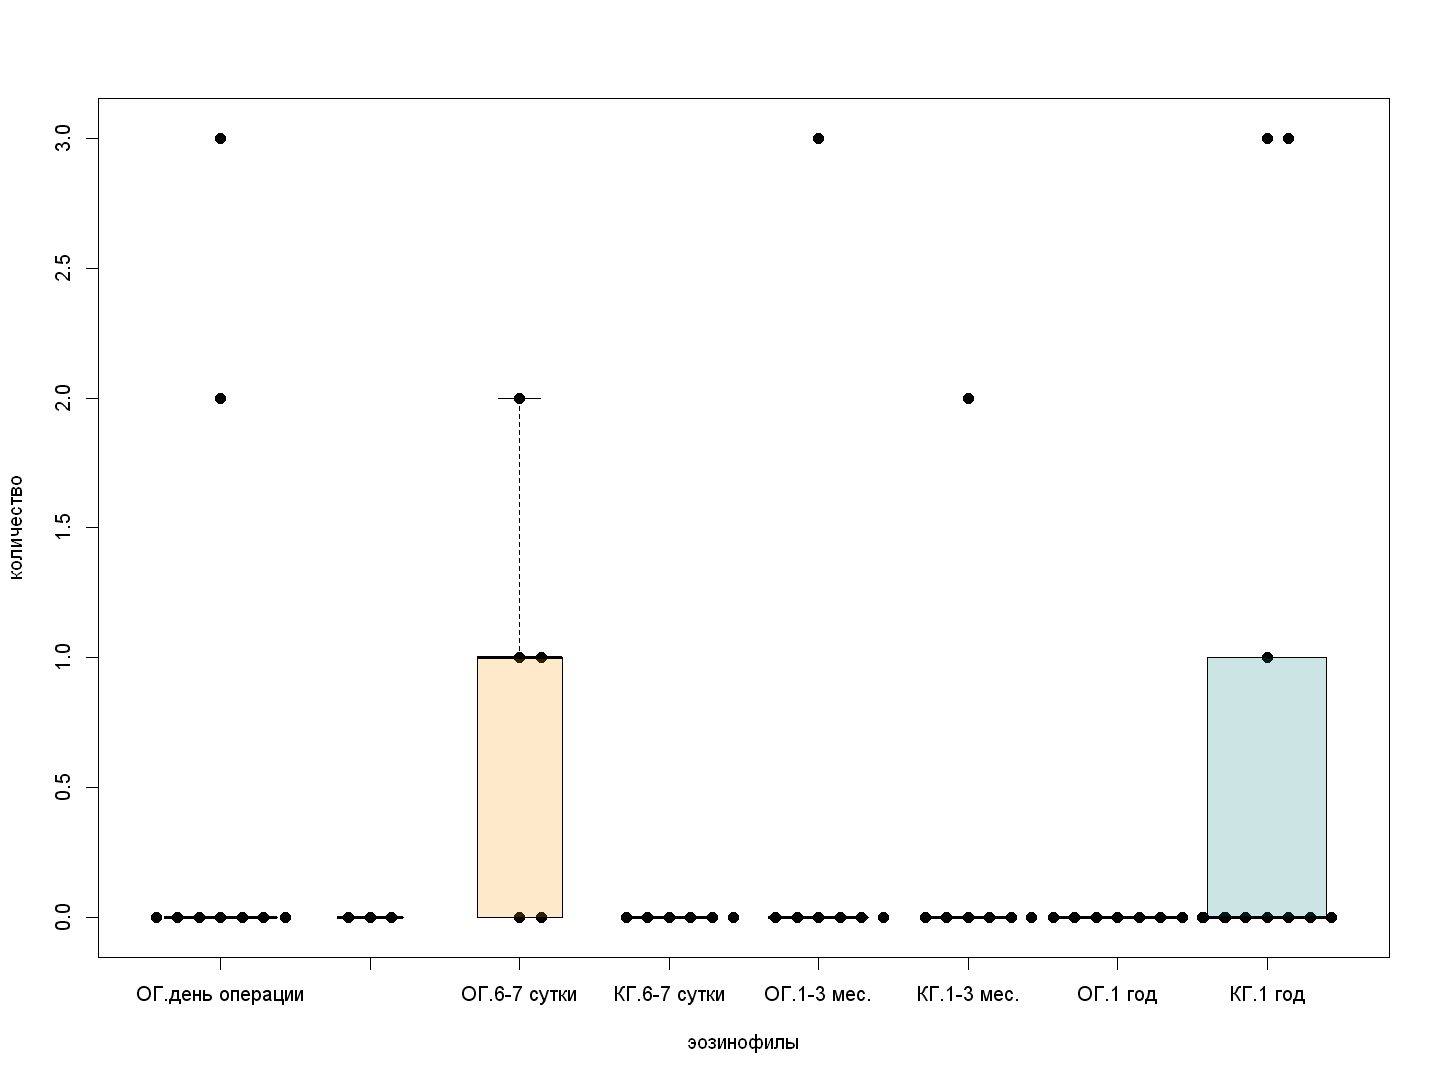

In [47]:
parname = sub("\\..*", "", parname)
beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
         , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", add = TRUE, varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [48]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 16.5, p-value = 0.4773
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.8528, p-value = 0.3938
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 24, p-value = 0.04758
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 2.0976, p-value = 0.03594
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 21, p-value = 1
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0, p-value = 1
alternative hy

## нейтрофилы

### Общее

In [49]:
parname = "нейтрофилы"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

In [50]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [51]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd  IQR 0% 25% 50%  75% 100% data:n
КГ: 1-3 мес.      1.0000000 1.5491933 2.25  0   0 0.0 2.25    3      6
КГ: 1 год         0.0000000 0.0000000 0.00  0   0 0.0 0.00    0     10
КГ: 6-7 сутки     1.5000000 1.0488088 1.00  0   1 1.5 2.00    3      6
КГ: день операции 0.0000000 0.0000000 0.00  0   0 0.0 0.00    0      3
ОГ: 1-3 мес.      0.0000000 0.0000000 0.00  0   0 0.0 0.00    0      7
ОГ: 1 год         0.0000000 0.0000000 0.00  0   0 0.0 0.00    0     10
ОГ: 6-7 сутки     0.6000000 0.5477226 1.00  0   0 1.0 1.00    1      5
ОГ: день операции 0.1111111 0.3333333 0.00  0   0 0.0 0.00    1      9

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0.0,0.00,1,0.1111111,0.3333333,9,0
КГ.день операции,0,0,0.0,0.00,0,0.0000000,0.0000000,3,0
ОГ.6-7 сутки,0,0,1.0,1.00,1,0.6000000,0.5477226,5,0
КГ.6-7 сутки,0,1,1.5,2.00,3,1.5000000,1.0488088,6,0
ОГ.1-3 мес.,0,0,0.0,0.00,0,0.0000000,0.0000000,7,0
КГ.1-3 мес.,0,0,0.0,2.25,3,1.0000000,1.5491933,6,0
ОГ.1 год,0,0,0.0,0.00,0,0.0000000,0.0000000,10,0
КГ.1 год,0,0,0.0,0.00,0,0.0000000,0.0000000,10,0


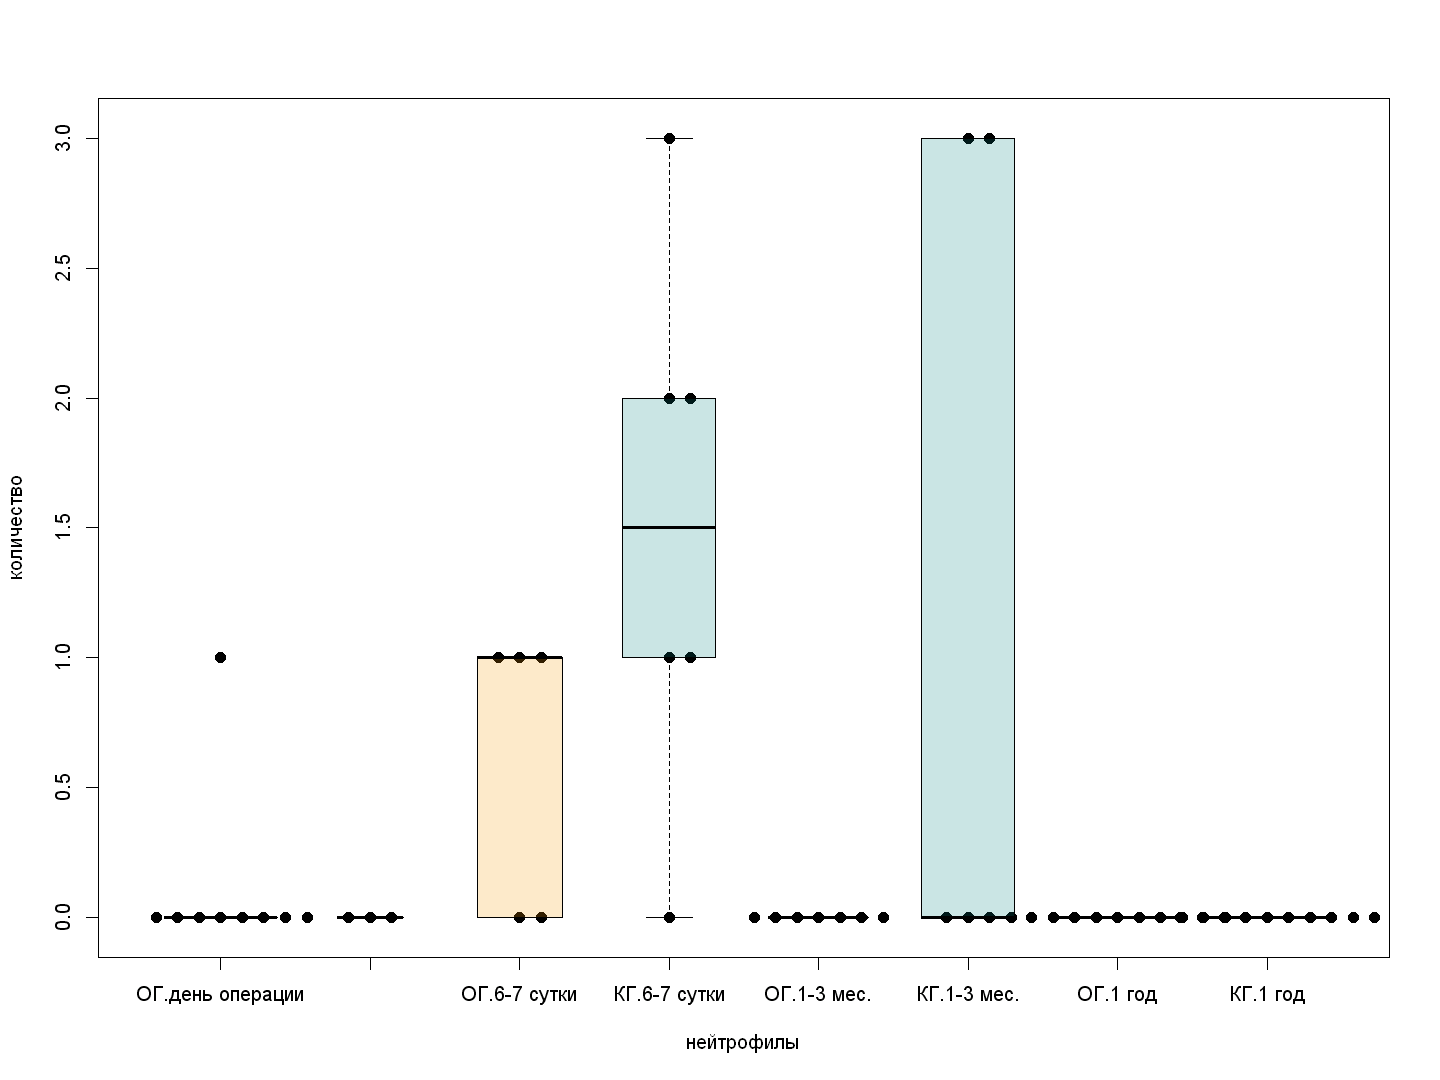

In [52]:
parname = sub("\\..*", "", parname)
beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
         , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", add = TRUE, varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [53]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 15, p-value = 0.7003
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.57735, p-value = 0.5637
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 7, p-value = 0.1458
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -1.5514, p-value = 0.1208
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 14, p-value = 0.1385
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -1.5954, p-value = 0.1106
a